In [1]:
import os
import sys

import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from qmplot import qqplot

import os
import sys
import yaml
import logging
import muon as mu
import pandas as pd
import cnmf
import scanpy as sc

# Change path to wherever you have repo locally
sys.path.append('/oak/stanford/groups/engreitz/Users/ymo/Tools/cNMF_benchmarking/cNMF_benchmarking_pipeline')

from Evaluation.src import (
    compute_perturbation_association,
)


/home/users/ymo/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# IO path
out_dir = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Result/012726_100k_cells_20iter_allHVG_torch_halsvar_batch_e7"
run_name = "012726_100k_cells_20iter_allHVG_torch_halsvar_batch_e7_all"

# resourse path
mdata_guide_path = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Data/withguide.h5ad"
guide_annotation_path = "/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Data/300genes_guide_metadata_v43.tsv"
reference_gtf_path="/oak/stanford/groups/engreitz/Users/opushkar/genome/IGVFFI9573KOZR.gtf.gz"

# keys 
data_key = 'rna'
prog_key = "cNMF"
categorical_key="timepoint"
organism = "human"
samples = ['d0', 'd1', 'd2', 'd3']

# run variables
components = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100 , 150, 200, 250, 300]
sel_threshs = [0.2, 2.0]

In [4]:
# reformat if needed 
mdata_guide = mu.read(mdata_guide_path)     

# helper method 
def _assign_guide(mdata):
        mdata[data_key].obsm['guide_assignment'] = mdata[data_key].obsm['guide_assignment'].toarray()
        mdata[prog_key].obsm['guide_assignment'] = mdata[prog_key].obsm['guide_assignment'].toarray()    

# Compute real perturbation test

In [ ]:
df_target = pd.read_csv(guide_annotation_path, sep = "\t", index_col = 0)
df_target_non = df_target[df_target["targeting"]==False]
reference_targets = df_target_non.index.values.tolist()

for sel_thresh in sel_threshs:
    for k in components:  

        output_folder = f"{out_dir}/{run_name}/Eval/{k}_{str(sel_thresh).replace('.','_')}"

        os.makedirs(output_folder, exist_ok=True)

        # Load mdata
        mdata = mu.read('{out_dir}/{run_name}/adata/cNMF_{k}_{sel_thresh}.h5mu'.format(out_dir = out_dir,
                                                                                run_name =run_name,
                                                                                k=k,
                                                                                sel_thresh = str(sel_thresh).replace('.','_'))) 
                                                                      
        # assign guide
        _assign_guide(mdata, mdata_guide)   


        # Run perturbation assocation
        for samp in mdata['rna'].obs[categorical_key].unique():
            mdata_ = mdata[mdata['rna'].obs[categorical_key]==samp]
            test_stats_df = compute_perturbation_association(mdata_, prog_key=prog_key, 
                                                            collapse_targets=True,
                                                            pseudobulk=False,
                                                            reference_targets=reference_targets,
                                                            FDR_method = 'StoreyQ',
                                                            n_jobs=-1, inplace=False)

            test_stats_df.to_csv('{}/{}_perturbation_association_results_{}.txt'.format(output_folder,k,samp), sep='\t', index=False)

# Compute fake perturbation test

In [4]:
# define variables
number_run = 10
number_guide = 6

In [11]:
# Load guide target
guide_annotation_path = '/oak/stanford/groups/engreitz/Users/ymo/IGVF_ccperturbseq/Data/300genes_guide_metadata_v43.tsv' 

guide_target = pd.read_csv(guide_annotation_path, sep='\t')
non_targeting_idx = guide_target.index[guide_target.targeting==False]  

guide_target = guide_target.loc[non_targeting_idx]
guide_target.type = "non-targeting"

In [ ]:
# Calibrate tests using "fake_target guides"
test_stats_fake_dfs = []


for sel_thresh in sel_threshs:
    for k in components:  
        print(f"Processing K={k}, sel_thresh={sel_thresh}")

        # Load mdata
        output_folder = f"{out_dir}/{run_name}/Eval/{k}_{str(sel_thresh).replace('.','_')}"
        os.makedirs(output_folder, exist_ok=True)
        mdata = mu.read('{out_dir}/{run_name}/adata/cNMF_{k}_{sel_thresh}.h5mu'.format(out_dir = out_dir,
                                                                                run_name =run_name,
                                                                                k=k,
                                                                                sel_thresh = str(sel_thresh).replace('.','_')))  

        # assign guide
        _assign_guide(mdata) 

        test_stats_fake_dfs_temp = []
        for i in range(number_run):
            print(f"Running iteration {i+1}/{number_run} for {k} and {sel_thresh}")       

            # randomly make number_guide non-targeting guides targeting 
            guide_target_ = guide_target.copy()
            selected_guides = np.random.choice(guide_target_.guide_names, number_guide, replace=False)
            guide_target_.loc[guide_target_.guide_names.isin(selected_guides), 'type'] = 'targeting'
            
            
            # Filter to only non-targeting guides that exist in both datasets
            valid_guide_mask = np.isin(mdata['cNMF'].uns['guide_names'], guide_target_.guide_names.values)
            valid_indices = np.where(valid_guide_mask)[0]
            
            print(f"Found {len(valid_indices)} valid non-targeting guides out of {len(mdata['cNMF'].uns['guide_names'])} total")
            
            if len(valid_indices) == 0:
                raise ValueError("No valid guides found")

            _mdata = mdata.copy()
            _mdata['cNMF'].obsm['guide_assignment'] = mdata['cNMF'].obsm['guide_assignment'][:, non_targeting_idx]
            _mdata['cNMF'].uns['guide_names'] = mdata['cNMF'].uns['guide_names'][non_targeting_idx]
            _mdata['cNMF'].uns['guide_targets'] = guide_target_.loc[guide_target_.guide_names.isin(mdata['cNMF'].uns['guide_names']), 'type'].values


            # Run perturbation assocation
            for samp in _mdata['rna'].obs[categorical_key].unique():
                mdata_samp = _mdata[_mdata['rna'].obs[categorical_key]==samp]
                test_stats_df = compute_perturbation_association(mdata_samp, prog_key=prog_key, 
                                                                collapse_targets=True,
                                                                pseudobulk=False,
                                                                reference_targets=['non-targeting'],
                                                                FDR_method = 'BH',
                                                                n_jobs=-1, inplace=False)

                test_stats_df[categorical_key] = samp
                test_stats_df['K'] = k
                test_stats_df['run'] = i
                test_stats_df['sel_thresh'] = sel_thresh
                test_stats_fake_dfs.append(test_stats_df) # combine all
                test_stats_fake_dfs_temp.append(test_stats_df) # combine for each k and sel_thresh

        # save fake test results
        test_stats_fake_dfs_temp = pd.concat(test_stats_fake_dfs_temp, ignore_index=True)
        test_stats_fake_dfs_temp.to_csv(f'{output_folder}/{k}_fake_perturbation_association_calibration.txt', sep='\t', index=False)

Processing K=10, sel_thresh=0.2
Running iteration 1/10 for 10 and 0.2
Found 120 valid non-targeting guides out of 1922 total


Testing perturbation association: 100%|██████████| 1/1 [00:00<00:00,  7.70targets/s]


In [ ]:
# save fake test results
test_stats_fake_dfs = pd.concat(test_stats_fake_dfs)
test_stats_fake_dfs.to_csv('{out_dir}/{run_name}/Eval/perturbation_association_calibration.txt', sep='\t', index=False)

# compare

In [3]:
# or load this way 

# if already have peturbation test data, read data 
test_stats_real_df = []

for sel_thresh in sel_threshs:
    for k in components:  
        for samp in samples:
            thresh_str = str(sel_thresh).replace('.', '_')
            test_stats_df_ = pd.read_csv(f'{out_dir}/{run_name}/Eval/{k}_{thresh_str}/{k}_perturbation_association_results_{samp}.txt', sep='\t')
            test_stats_df_['sample'] = samp
            test_stats_df_['K'] = k
            test_stats_df_['sel_thresh'] = sel_thresh
            #test_stats_df_['fdr'] = fdrcorrection(test_stats_df_['pval'])[1]
            test_stats_real_df.append(test_stats_df_)

# Concatenate AFTER all loops are done
test_stats_real_df = pd.concat(test_stats_real_df, ignore_index=True)
test_stats_real_df['real'] = True

# if already have fake peturbation test data, read data 
# test_stats_fake_dfs = pd.read_csv('/oak/stanford/groups/engreitz/Users/ymo/cc-perturb-seq/Data/perturbation_association_calibration.txt', sep='\t')

# or load this way
test_stats_fake_df = []
for sel_thresh in sel_threshs:
    for k in components:  
        thresh_str = str(sel_thresh).replace('.', '_')
        test_stats_df_ = pd.read_csv(f'{out_dir}/{run_name}/Eval/{k}_{thresh_str}/{k}_fake_perturbation_association_results.txt', sep='\t')
        #test_stats_df_['fdr'] = fdrcorrection(test_stats_df_['pval'])[1]
        test_stats_fake_df.append(test_stats_df_)

# Concatenate AFTER all loops are done
test_stats_fake_df = pd.concat(test_stats_fake_df, ignore_index=True)
test_stats_fake_df['real'] = False

# merge
test_stats_dfs = pd.concat([test_stats_real_df, test_stats_fake_df])

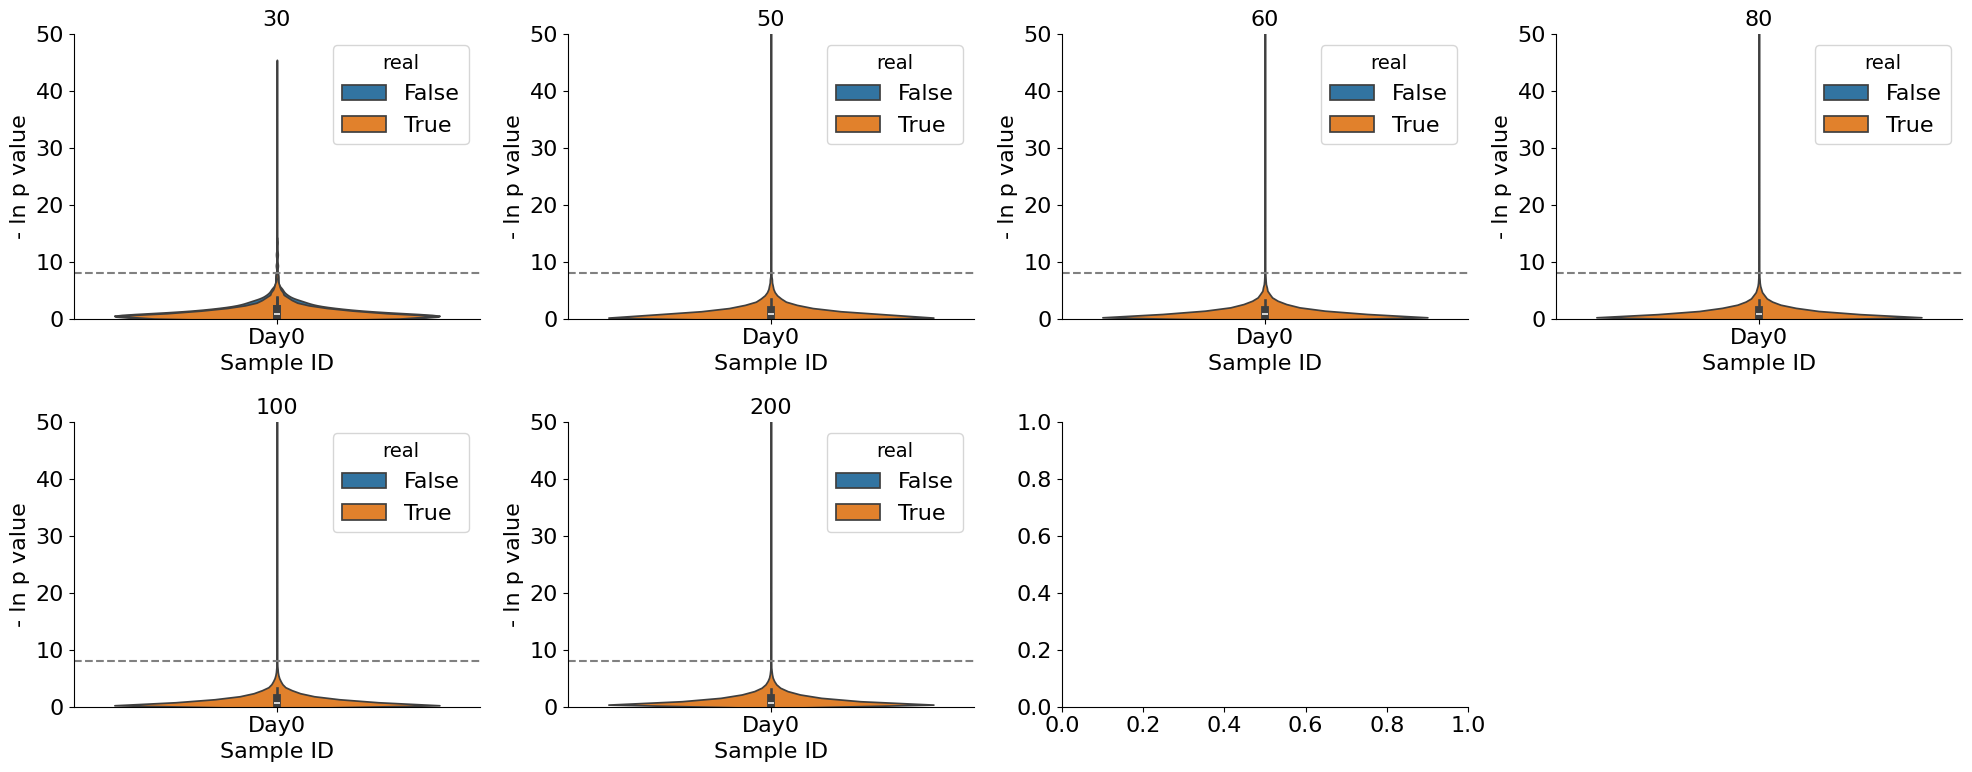

In [ ]:
nrows = int(len(components)/4) +1 

fig, axs = plt.subplots(ncols=4, nrows=nrows, figsize=(20,8))
for i,k in enumerate(components):

    test_stats_dfs['neg_log_pval'] = test_stats_dfs['pval'].apply(lambda x: -np.log(x))
    sns.violinplot(x='sample', y='neg_log_pval', hue='real', data=test_stats_dfs.loc[test_stats_dfs.K==k], ax=axs.flat[i])
    axs.flat[i].set_title(str(k))
    axs.flat[i].set_xlabel('Sample ID')
    axs.flat[i].set_ylabel('- ln p value')
    axs.flat[i].set_ylim(0,50)
    axs.flat[i].axhline(8, color='grey', linestyle='dashed')

axs.flat[-1].axis('off')
plt.tight_layout()

plt.savefig(f'{out_dir}/{run_name}/Plot/QQ_plot/perturbation_association_calibration.png', dpi=100)

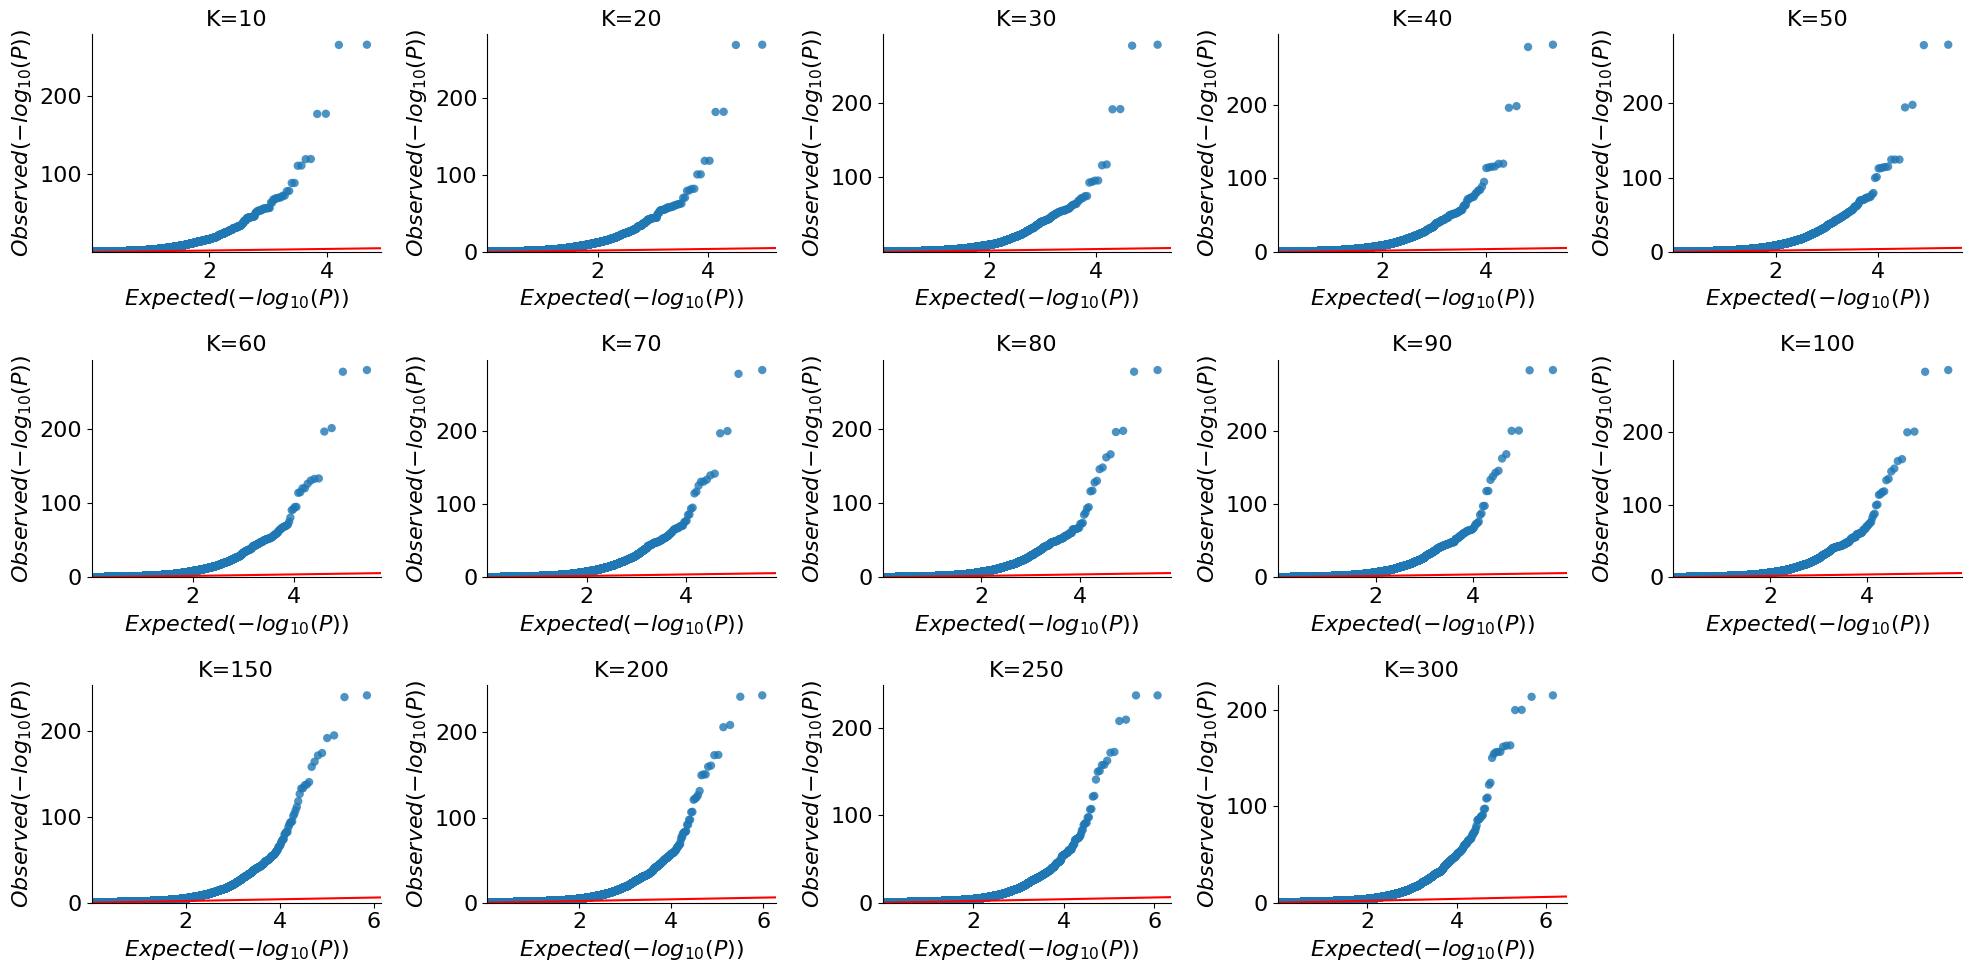

In [ ]:
# QQ plot real
nrows = int(len(components)/4) +1 

fig, axs = plt.subplots(ncols=4, nrows=nrows, figsize=(20,10))
for i,k in enumerate(components):

    qqplot(data=test_stats_dfs.loc[(test_stats_dfs.K==k) & (test_stats_dfs.real==True), 'pval'], ax=axs.flat[i])
    axs.flat[i].set_title(f'K={k}')



axs.flat[-1].axis('off')
plt.tight_layout()

plt.savefig(f'{out_dir}/{run_name}/Plot/QQ_plot/perturbation_association_qqplot_real.png', dpi=100)

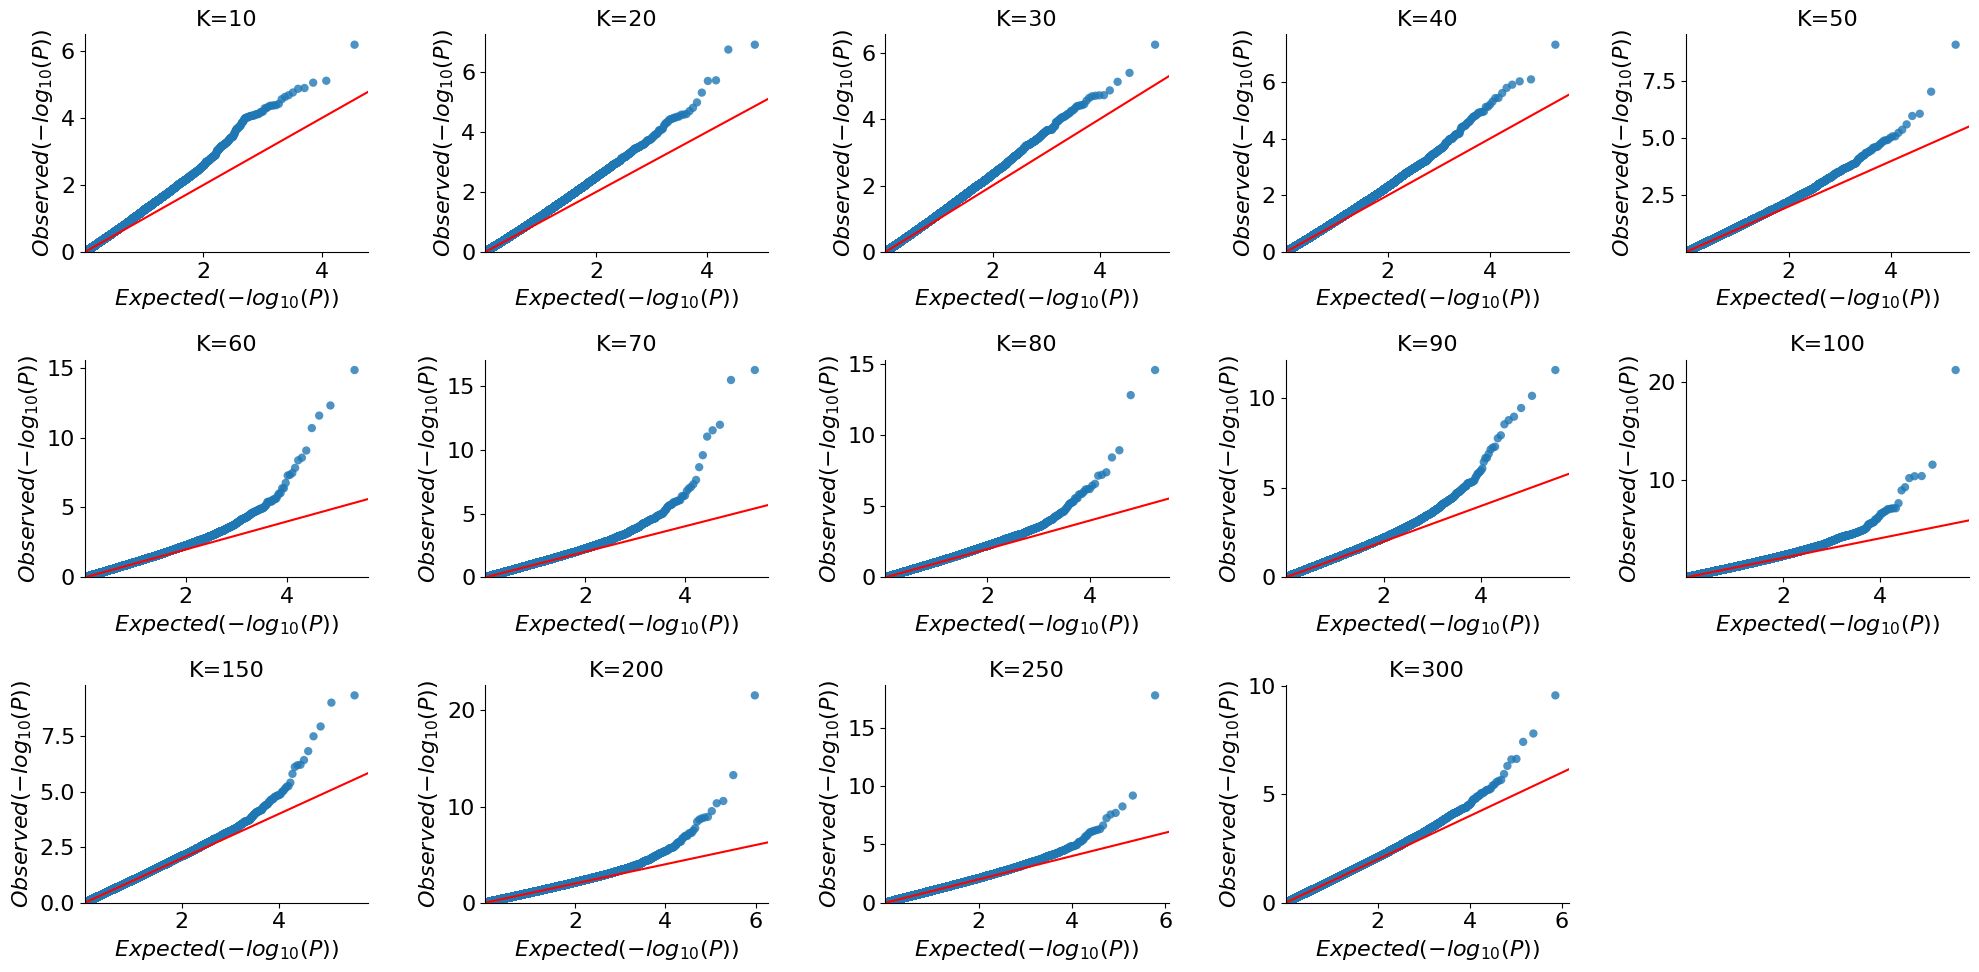

In [ ]:
 # QQ plot fake
nrows = int(len(components)/4) +1 

fig, axs = plt.subplots(ncols=4, nrows=nrows, figsize=(20,10))
for i,k in enumerate(components):

    qqplot(data=test_stats_dfs.loc[(test_stats_dfs.K==k) & (test_stats_dfs.real==False)& (test_stats_dfs.target_name=='targeting'), 'pval'], ax=axs.flat[i])
    axs.flat[i].set_title(f'K={k}')

axs.flat[-1].axis('off')
plt.tight_layout()

plt.savefig(f'{out_dir}/{run_name}/Plot/QQ_plot/perturbation_association_qqplot_fake.png', dpi=100)

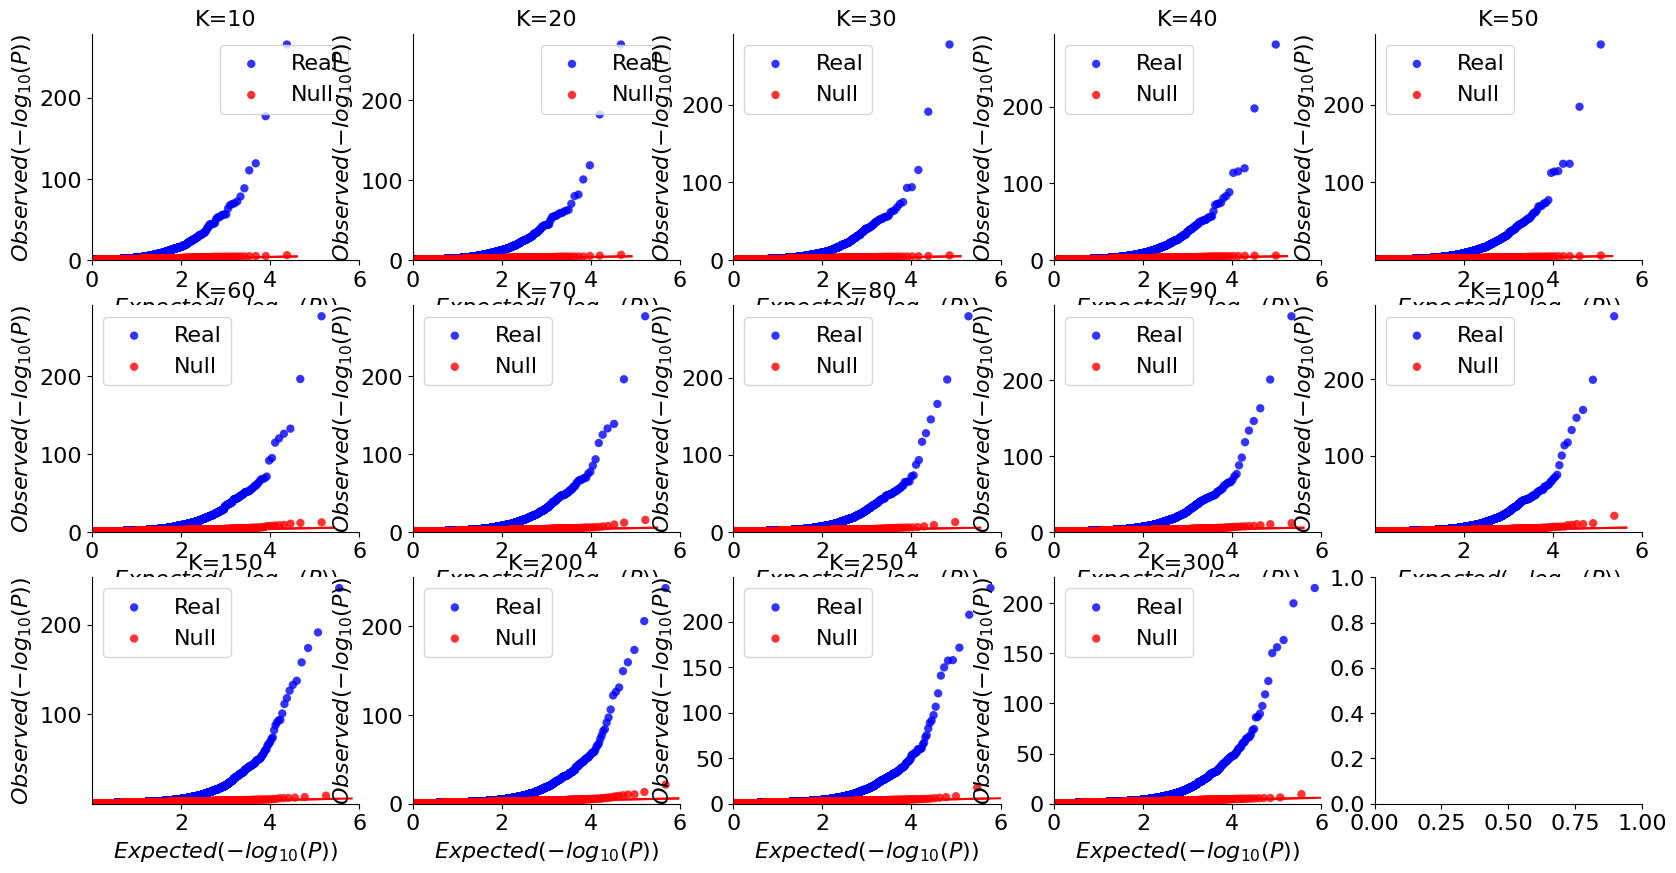

In [ ]:
# combine 
nrows = int(len(components)/4) +1 
fig, axs = plt.subplots(ncols=4, nrows=nrows, figsize=(20, 10))

sel_thresh = 0.2

for i, k in enumerate(components):
    ax = axs.flat[i]
    
    # Get data for both real and null
    real_pvals = test_stats_dfs.loc[(test_stats_dfs.K == k) & (test_stats_dfs.real == True) & (test_stats_dfs.sel_thresh == sel_thresh), 'pval']
    null_pvals = test_stats_dfs.loc[(test_stats_dfs.K == k) & (test_stats_dfs.real == False) & (test_stats_dfs.target_name == 'targeting') & (test_stats_dfs.sel_thresh == sel_thresh), 'pval']
    
    # Real data
    qqplot(
        data=real_pvals,
        ax=ax,
        color='blue',
        label='Real'
    )
    
    # Null data
    qqplot(
        data=null_pvals,
        ax=ax,
        color='red',
        label='Null'
    )
    
    # Get current axis limits (after both plots are drawn)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Expand limits independently to include all data from both axes
    max_x = max(xlim[1], ylim[0])
    min_x = min(xlim[0], ylim[0])
    max_y = max(xlim[1], ylim[1])
    min_y = min(xlim[0], ylim[0])
    
    ax.set_xlim(min_x, 6)
    ax.set_ylim(min_y, max_y)
    
    ax.set_title(f'K={k}')
    ax.legend()

plt.savefig(f'{out_dir}/{run_name}/Plot/QQ_plot/perturbation_association_qqplot_overlap_{str(sel_thresh).replace(".", "_")}.png', dpi=100)